<a href="https://colab.research.google.com/github/akashsinghsharma/deep_learning/blob/main/45_Basic_ANN_for_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') ## This is setting the default of matplotlib in svg output, we can get pdf, png as well.

In [81]:
# Create Data

N = 30
x = torch.rand(N,1)  # This creates a tensor of length 30. N*1 is the size of tensor here.
y = x + torch.rand(N,1)/2  #This is adding some noise in y. x is independend variable, y is dependent and have some linear relation with x, along with some added noise.

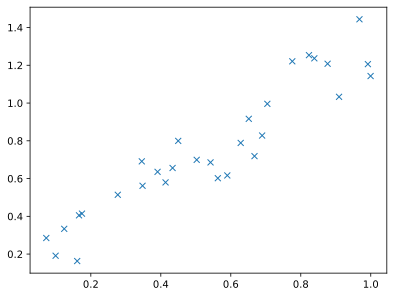

In [82]:
plt.plot(x,y,'x')
plt.show()

In [83]:
## Building Model

### This model have 2 linear layer, 1 behaving as input and 1 in end behavinga s output. It is usng RELU as it's non linear activation function.

ANNreg = nn.Sequential(
    nn.Linear(1,1), # Input layer with 1 input and 1 output, output passed to relu
    nn.ReLU(),
    nn.Linear(1,1) # output layer, taking 1 input and 1 output.
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

Here bias term is added by default.

Note - In code above, we are creating a object that will be trained. It's like a pipeline where data will flow.

In [84]:
learningRate = 0.05

lossfun = nn.MSELoss() # This creates a instance of loss function Mean squared error.

# optimizer (the flavor of gradient descent to implement)
optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learningRate)   #(more on this later)

In [85]:
# train the model
numepochs = 500
losses = torch.zeros(numepochs)


## Train the model!
for epochi in range(numepochs):

  # forward pass
  yHat = ANNreg(x) # Computing predicted y value

  # compute loss
  loss = lossfun(yHat,y)
  losses[epochi] = loss  # will use this for vizulization

  # backprop
  optimizer.zero_grad() # Reinitializing all to zero.
  loss.backward()
  optimizer.step() #Some housekepping is done here, more on last 3 lines later.

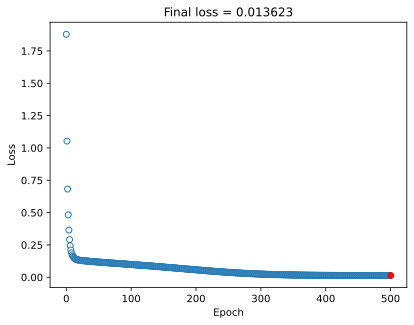

In [86]:
# show the losses

# manually compute losses
# final forward pass
predictions = ANNreg(x)

# final loss (MSE)
testloss = (predictions-y).pow(2).mean()

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.plot(numepochs,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()

The above is kind of graph we should see in training, i.e. loss getting smaller as we train more and more. Although one can say we trained too long for here, as it becomes asymotode.

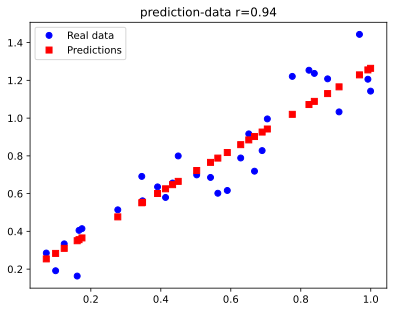

In [87]:
# plot the data
plt.plot(x,y,'bo',label='Real data')
plt.plot(x,predictions.detach(),'rs',label='Predictions') #detach() is used here as that variable prediction have other things in it too.
plt.title(f'prediction-data r={np.corrcoef(y.T,predictions.detach().T)[0,1]:.2f}')
plt.legend()
plt.show()

A lot of time when I am running the code, I can see a flat prediction, so model is not learning well. Dig more around this.